# VS onset + lag GLM · nine comparison plans

All plans retain the existing XY + eye correction, angle offset, allocentric HD,
onset events, nonnegative VS FIR lags, spike bins, and shared train/test rows.

| Plan | Additional X/Y | −100 ms | VS ego pose | Additive HD | Omega FIR |
|---|---|---|---|---|---|
| 1 | Yes | Angle + white/gray | Onset | Onset | None |
| 2 | Yes | White/gray | Onset | Onset | None |
| 3 | No | Angle + white/gray | Onset | Onset | None |
| 4 | No | White/gray | Onset | Onset | None |
| 5 | Yes | Angle + white/gray | Bin start | Bin start | None |
| 6 | No | None | Onset | Onset | None |
| 7 | No | None | Onset | Onset | Onset |
| 8 | No | None | Onset | Onset | Bin start |
| 9 | No | None | Bin start | Onset | Bin start |

At −100 ms, find the trial containing the exact `onset - 0.1` time; gray gives zero.
At nonnegative lags, retain the original 0-ms onset's stimulus position, including
after another VS appears. Plans 5 and 9 update pose, not the onset event train.

Omega is signed `(unwrapped_HD(t) - unwrapped_HD(t - 50 ms)) / 0.05`, in deg/s.
Plan 7 samples omega at each trial onset and holds it through that trial; plans 8/9
sample it at every bin start. All three use the same nonnegative FIR lag grid as VS.
Plans 6–9 hold additive HD at the current trial onset, so 7−6 adds omega, 8−7 changes
omega sampling, and 9−8 changes only VS ego-pose sampling. The existing +offset is unchanged.


In [2]:
import json
import sys
from pathlib import Path

import jax
import matplotlib.pyplot as plt
import nemos as nmo
import numpy as np
import pandas as pd
from scipy.io import loadmat
from scipy.spatial.transform import Rotation

sys.path.append(str(Path.cwd().parent))
from Utils.tuning_curve_utils import get_exposure_timestamps

session_ID: int = 10
session_dir = Path(f"/mnt/senzailab/Kai/#Recording/m19/260827/260827_{session_ID}")

data_dir = session_dir / "data"
kilosort_dir = session_dir / f"kilosort/ProbeA/kilosort_{session_ID}"
calibration_path = session_dir / "260821.calib"
output_dir = data_dir / "glm"
unit_id = 261
bin_size = 0.02
angle_bin_size = 12
pre_onset_lag = -0.1
max_lag = 0.25
train_fraction = 0.8
regularizer_strength = 0.001
random_seed = 0
headplate_name = "hp4"
camera_input_channel = 1
camera_ttl_threshold = 14000

omega_window = 0.05  # Signed HD change over the preceding 50 ms.


## 1. 读 mat file

In [3]:
session_metadata = json.loads((data_dir / "session_info.json").read_text())
session_info = session_metadata["session_info"]
session_name = Path(session_info["base_path"]).name
trials = loadmat(
    session_dir / f"{session_name}.mat", simplify_cells=True,
)["trials"]

spike_samples = np.load(kilosort_dir / "spike_times.npy")
spike_clusters = np.load(kilosort_dir / "spike_clusters.npy")
unit_info = np.genfromtxt(
    kilosort_dir / "cluster_KSLabel.tsv",
    delimiter="\t", names=True, dtype=None, encoding="utf-8",
)
unit_label = unit_info["KSLabel"][unit_info["cluster_id"] == unit_id][0]
unit_mask = spike_clusters == unit_id

on_list_times = np.load(data_dir / "on_list_times.npy")


# Real HD is frame-indexed; the raw camera TTL supplies ADC-clock times.
hd_path = data_dir / "processed/head_direction.json"
hd_payload = json.loads(hd_path.read_text())[headplate_name]
hd_frames_all = np.asarray(hd_payload["frames"], dtype=int)
frame_head_direction_all = np.asarray(
    hd_payload["head_direction_deg"], dtype=float,
)
frame_times_relative, adc_time_origin, ttl_qc = get_exposure_timestamps(
    session_info, camera_input_channel, camera_ttl_threshold,
    camera_ttl_active_high=True,
)
camera_frame_times = frame_times_relative + adc_time_origin
# Session 5 Motive recording continued after Open Ephys stopped.
# Frame zero matches the first TTL; only unmatched trailing Motive frames are dropped.
hd_trailing_frame_count = len(frame_head_direction_all) - len(camera_frame_times)
hd_frames = hd_frames_all[:len(camera_frame_times)]
frame_head_direction = frame_head_direction_all[:len(camera_frame_times)] % 360

calibration = json.loads(calibration_path.read_text())
motive = pd.read_csv(
    session_dir / f"{session_name}.csv",
    header=[2, 3, 6, 7], skip_blank_lines=False,
)
frame_hp4_position = motive["Rigid Body"][headplate_name]["Position"][
    ["X", "Y", "Z"]
].to_numpy()[:len(camera_frame_times)]
frame_hp4_rotation = motive["Rigid Body"][headplate_name]["Rotation"][
    ["X", "Y", "Z"]
].to_numpy()[:len(camera_frame_times)]
frame_eye_offset = Rotation.from_euler(
    "XYZ", frame_hp4_rotation, degrees=True,
).apply(np.asarray(calibration["hp_to_eye_center"]))
frame_eye_position = frame_hp4_position + frame_eye_offset
screen_zero_deg = calibration["screen_center"]
screen_center_xy = np.asarray(calibration["screen_bottom_center"][:2])
screen_radius = calibration["screen_diamter"] / 2


## 4. XY + eye correction：onset pose / response-bin-start pose


In [4]:
vs_info = {
    "start": on_list_times[:-1],
    "end": on_list_times[1:],
    "position": np.array([trial["Square_PositionX"] for trial in trials]),
    "luminance": np.array([trial["Square_Luminance"] for trial in trials]),
}
bin_count = int((on_list_times[-1] - on_list_times[0]) / bin_size)
time_edges = on_list_times[0] + np.arange(bin_count + 1) * bin_size
bin_start = time_edges[:-1]
time = bin_start + bin_size / 2
trial_index = np.searchsorted(on_list_times, bin_start, side="right") - 1
white_trial = vs_info["luminance"] == 1
white = white_trial[trial_index]
hd_unwrapped = np.unwrap(np.radians(frame_head_direction))


def pose_at(sample_times):
    hd = np.degrees(np.interp(sample_times, camera_frame_times, hd_unwrapped)) % 360
    hp4_xy = np.column_stack([
        np.interp(sample_times, camera_frame_times, frame_hp4_position[:, axis])
        for axis in range(2)
    ])
    eye_offset_xy = np.column_stack([
        np.interp(sample_times, camera_frame_times, frame_eye_offset[:, axis])
        for axis in range(2)
    ])
    return hd, hp4_xy, hp4_xy + eye_offset_xy


def corrected_vs_position(raw_position, observer_xy, hd):
    # Keep the existing screen geometry and +180 offset for all nine plans.
    raw_position = np.asarray(raw_position)
    screen_angle = np.radians(raw_position + screen_zero_deg)
    bar_xy = screen_center_xy + screen_radius * np.column_stack([
        np.cos(screen_angle), np.sin(screen_angle),
    ])
    ray_xy = bar_xy - observer_xy
    bar_bearing = np.degrees(np.arctan2(ray_xy[:, 1], ray_xy[:, 0]))
    center_bearing = raw_position + screen_zero_deg
    bearing_delta = (bar_bearing - center_bearing + 180) % 360 - 180
    return (raw_position + 180 + hd + bearing_delta) % 360


def angular_velocity_at(sample_times):
    # Unwrap before differencing so a 359 -> 1 crossing remains a small turn.
    angle_now = np.interp(sample_times, camera_frame_times, hd_unwrapped)
    angle_before = np.interp(np.asarray(sample_times) - omega_window, camera_frame_times, hd_unwrapped)
    return np.degrees(angle_now - angle_before) / omega_window


# Frozen geometry is evaluated at each trial's own onset, including gray trials.
onset_hd, onset_hp4_xy, onset_eye_xy = pose_at(vs_info["start"])
onset_position = corrected_vs_position(vs_info["position"], onset_eye_xy, onset_hd)
bin_hd, bin_hp4_xy, bin_eye_xy = pose_at(bin_start)

# One white-onset event per white trial; gray bins remain on the timeline.
onset_trials = np.flatnonzero(white_trial)
onset_bin = np.searchsorted(time_edges, vs_info["start"][onset_trials], side="right") - 1
onset = np.zeros(bin_count, dtype=int)
np.add.at(onset, onset_bin[onset_bin < bin_count], 1)


## 5. 建立 unit spike time 和每个 bin 的 spike count

In [5]:
# 已按 Kilosort 行顺序映射到 ADC clock；不要直接 samples / sample_rate。
adc_spike_times = np.load(data_dir / "probeA/adc_spike_time.npy")
unit_spike_times = adc_spike_times[unit_mask]
unit_spike_samples = spike_samples[unit_mask]
spike_counts = np.histogram(unit_spike_times, time_edges)[0]


## 6. Binary RF angle basis + nonnegative FIR lags


In [6]:
# jax.config.update("jax_enable_x64", True)
angle_count = 360 // angle_bin_size
angle_edges = np.arange(angle_count + 1) * angle_bin_size
angle_centers = (angle_edges[:-1] + angle_edges[1:]) / 2
angle_basis = np.eye(angle_count)
lag_steps = np.arange(round(max_lag / bin_size) + 1)
lags = lag_steps * bin_size
lag_basis = np.eye(len(lags))
rf_feature_count = len(lags) * angle_count

plan_specs = {
    "plan1": dict(xy=True, pre="angle", dynamic=False, hd_dynamic=False, omega=None),
    "plan2": dict(xy=True, pre="white", dynamic=False, hd_dynamic=False, omega=None),
    "plan3": dict(xy=False, pre="angle", dynamic=False, hd_dynamic=False, omega=None),
    "plan4": dict(xy=False, pre="white", dynamic=False, hd_dynamic=False, omega=None),
    "plan5": dict(xy=True, pre="angle", dynamic=True, hd_dynamic=True, omega=None),
    "plan6": dict(xy=False, pre=None, dynamic=False, hd_dynamic=False, omega=None),
    "plan7": dict(xy=False, pre=None, dynamic=False, hd_dynamic=False, omega="onset"),
    "plan8": dict(xy=False, pre=None, dynamic=False, hd_dynamic=False, omega="bin"),
    "plan9": dict(xy=False, pre=None, dynamic=True, hd_dynamic=False, omega="bin"),
}


## 7. Nine designs：onset RF + HD + selected pre / X/Y / omega terms

The −100 ms angle belongs to the trial at that time, not the future 0-ms trial.
It is a separate control, not the negative-lag column of the 0-ms trial's RF.
Plans 1–5 share a white/gray coefficient; spatial controls add centered angle contrasts.

Allocentric HD occurs once per response bin: only plan 5 uses bin-start HD; the others
hold the current trial's onset HD. Additional X/Y uses hp4 at the bin start in plans
1, 2, and 5. Omega is a continuous behavioral signal, including gray time. Its FIR
lags use past bins without circular wrapping. Scaling is fitted on training rows only.


In [7]:
def angle_index(angles):
    return np.floor((angles % 360) / angle_bin_size).astype(int)


def make_onset_lag_design(dynamic=False):
    result = np.zeros((bin_count, rf_feature_count))
    for lag_index, lag in enumerate(lag_steps):
        response_bins = onset_bin + lag
        valid = (response_bins >= 0) & (response_bins < bin_count)
        rows = response_bins[valid]
        sources = onset_trials[valid]
        # Keep this event's raw bar position, even when a later trial is on screen.
        angles = (
            corrected_vs_position(vs_info["position"][sources], bin_eye_xy[rows], bin_hd[rows])
            if dynamic else onset_position[sources]
        )
        np.add.at(result, (rows, lag_index * angle_count + angle_index(angles)), 1)
    return result


pre_times = vs_info["start"][onset_trials] + pre_onset_lag
pre_bins = np.searchsorted(time_edges, pre_times, side="right") - 1
pre_trials = np.searchsorted(on_list_times, pre_times, side="right") - 1
pre_valid = (pre_bins >= 0) & (pre_bins < bin_count) & (pre_trials >= 0)
pre_times, pre_bins, pre_trials = (
    value[pre_valid] for value in (pre_times, pre_bins, pre_trials)
)
pre_white = white_trial[pre_trials]


def make_pre_onset_control(dynamic=False):
    result = np.zeros((bin_count, angle_count))
    rows = pre_bins[pre_white]
    sources = pre_trials[pre_white]
    angles = (
        corrected_vs_position(vs_info["position"][sources], bin_eye_xy[rows], bin_hd[rows])
        if dynamic else onset_position[sources]
    )
    np.add.at(result, (rows, angle_index(angles)), 1)
    white_control = result.sum(axis=1, keepdims=True)
    # Shared white effect + zero-sum angle contrasts; gray is zero in every column.
    return white_control, result - white_control / angle_count


sample_index = np.arange(lag_steps[-1], bin_count)
# Complete past and future context for every plan, including the −100 ms control.
sample_index = sample_index[
    time_edges[sample_index + 1] - pre_onset_lag <= on_list_times[-1]
]
# Omega's oldest lag also needs the current trial onset's 50-ms camera history.
oldest_omega_time = vs_info["start"][trial_index[sample_index - lag_steps[-1]]] - omega_window
sample_index = sample_index[
    (oldest_omega_time >= camera_frame_times[0]) & (bin_start[sample_index] <= camera_frame_times[-1])
]
split_time = on_list_times[int(len(trials) * train_fraction)]
train = time_edges[sample_index + 1] <= split_time + pre_onset_lag
test = bin_start[sample_index] >= split_time + max_lag

vs_design = make_onset_lag_design()[sample_index]
vs_design_dynamic = make_onset_lag_design(dynamic=True)[sample_index]
pre_white_design, pre_position_design = make_pre_onset_control()
pre_white_dynamic, pre_position_dynamic = make_pre_onset_control(dynamic=True)
np.testing.assert_array_equal(pre_white_design, pre_white_dynamic)
pre_white_design = pre_white_design[sample_index]
pre_position_design = pre_position_design[sample_index]
pre_position_dynamic = pre_position_dynamic[sample_index]

frozen_hd = onset_hd[trial_index[sample_index]]
dynamic_hd = bin_hd[sample_index]
hd_raw = np.column_stack([np.cos(np.radians(frozen_hd)), np.sin(np.radians(frozen_hd))])
hd_dynamic_raw = np.column_stack([
    np.cos(np.radians(dynamic_hd)), np.sin(np.radians(dynamic_hd)),
])
hd_feature_mean = hd_raw[train].mean(axis=0)
hd_feature_scale = hd_raw[train].std(axis=0)
hd_features = (hd_raw - hd_feature_mean) / hd_feature_scale
hd_dynamic_features = (hd_dynamic_raw - hd_feature_mean) / hd_feature_scale
xy_raw = bin_hp4_xy[sample_index]
xy_feature_mean = xy_raw[train].mean(axis=0)
xy_feature_scale = xy_raw[train].std(axis=0)
xy_features = (xy_raw - xy_feature_mean) / xy_feature_scale

omega_onset_raw = angular_velocity_at(vs_info["start"])[trial_index]
omega_dynamic_raw = angular_velocity_at(bin_start)
omega_feature_mean = omega_onset_raw[sample_index][train].mean()
omega_feature_scale = omega_onset_raw[sample_index][train].std()
omega_design = np.column_stack([
    (omega_onset_raw[sample_index - lag] - omega_feature_mean) / omega_feature_scale
    for lag in lag_steps
])
omega_dynamic_design = np.column_stack([
    (omega_dynamic_raw[sample_index - lag] - omega_feature_mean) / omega_feature_scale
    for lag in lag_steps
])

rf_labels = [
    f"rf_{angle:g}_lag_{lag}"
    for lag in np.rint(lags * 1000).astype(int) for angle in angle_edges[:-1]
]
pre_label = f"pre_white_lag_{pre_onset_lag * 1000:g}"
pre_angle_labels = [f"pre_angle_{angle:g}_centered" for angle in angle_edges[:-1]]
omega_labels = [f"omega_z_lag_{lag}" for lag in np.rint(lags * 1000).astype(int)]
designs, design_labels = {}, {}
for name, spec in plan_specs.items():
    parts = [vs_design_dynamic if spec["dynamic"] else vs_design]
    labels = rf_labels.copy()
    if spec["pre"] is not None:
        parts.append(pre_white_design)
        labels += [pre_label]
    if spec["pre"] == "angle":
        parts.append(pre_position_dynamic if spec["dynamic"] else pre_position_design)
        labels += pre_angle_labels
    parts.append(hd_dynamic_features if spec["hd_dynamic"] else hd_features)
    labels += ["hd_cos_z", "hd_sin_z"]
    if spec["xy"]:
        parts.append(xy_features)
        labels += ["hp4_x_z", "hp4_y_z"]
    if spec["omega"] is not None:
        parts.append(omega_design if spec["omega"] == "onset" else omega_dynamic_design)
        labels += omega_labels
    designs[name] = np.column_stack(parts)
    design_labels[name] = labels

time = time[sample_index]
spike_counts = spike_counts[sample_index]
{name: design.shape for name, design in designs.items()}


{'plan1': (59972, 425),
 'plan2': (59972, 395),
 'plan3': (59972, 423),
 'plan4': (59972, 393),
 'plan5': (59972, 425),
 'plan6': (59972, 392),
 'plan7': (59972, 405),
 'plan8': (59972, 405),
 'plan9': (59972, 405)}

## 8. Fit exactly nine plans → predict


In [8]:
models, predicted_counts, generated_spike_counts = {}, {}, {}
rf, pre_rf, omega_kernels = {}, {}, {}
for name, design in designs.items():
    model = nmo.glm.GLM(
        observation_model=nmo.observation_models.PoissonObservations(),
        regularizer="Ridge", regularizer_strength=regularizer_strength,
        solver_name="LBFGS", solver_kwargs={"maxiter": 2000},
    )
    model.fit(design[train], spike_counts[train])
    models[name] = model
    predicted_counts[name] = np.asarray(model.predict(design))
    generated_spike_counts[name] = np.random.default_rng(random_seed).poisson(predicted_counts[name])
    coefficients = np.asarray(model.coef_)
    rf[name] = angle_basis @ coefficients[:rf_feature_count].reshape(len(lags), angle_count).T @ lag_basis.T
    if plan_specs[name]["pre"] is not None:
        pre_rf[name] = np.full(angle_count, coefficients[rf_feature_count])
    if plan_specs[name]["pre"] == "angle":
        angle_coefficients = coefficients[rf_feature_count + 1:rf_feature_count + 1 + angle_count]
        pre_rf[name] += angle_coefficients - angle_coefficients.mean()
    if plan_specs[name]["omega"] is not None:
        omega_kernels[name] = coefficients[-len(lags):]


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [9]:
pd.DataFrame({name: values[:5] for name, values in predicted_counts.items()})


,plan1,plan2,plan3,plan4,plan5,plan6,plan7,plan8,plan9
0,0.623154,0.623101,0.714608,0.714610,0.664581,0.714604,0.708318,0.711252,0.744758
1,0.654079,0.654042,0.743796,0.743885,0.679768,0.744517,0.729711,0.733163,0.751883
2,0.621063,0.603167,0.702605,0.675027,0.718187,0.664879,0.659624,0.657731,0.758312
3,0.651659,0.647807,0.728570,0.724425,0.634114,0.728648,0.721851,0.705959,0.685547
4,0.584188,0.583644,0.656505,0.655981,0.588212,0.656237,0.643829,0.643330,0.631486


## 9. Save nine-plan results


In [10]:
output_dir.mkdir(exist_ok=True)
np.savetxt(
    output_dir / f"{unit_id}_plans_vs_info.csv", np.column_stack(list(vs_info.values())),
    delimiter=",", header="start,end,position,luminance", comments="", fmt="%.18g",
)
np.savetxt(
    output_dir / f"{unit_id}_plans_spikes.csv", np.column_stack([unit_spike_samples, unit_spike_times]),
    delimiter=",", header="spike_samples,spike_times", comments="", fmt=["%d", "%.18g"],
)
np.savetxt(
    output_dir / f"{unit_id}_plans_pre_trials.csv",
    np.column_stack([pre_times, pre_bins, pre_trials, vs_info["position"][pre_trials], pre_white]),
    delimiter=",", header="pre_time,pre_bin,source_trial,raw_position,white", comments="", fmt="%.18g",
)
result_columns = [
    time, bin_start[sample_index], trial_index[sample_index],
    vs_info["position"][trial_index[sample_index]], white[sample_index],
    frozen_hd, dynamic_hd, *xy_raw.T, spike_counts, train, test,
    omega_onset_raw[sample_index], omega_dynamic_raw[sample_index],
]
result_labels = [
    "time", "bin_start", "trial_index", "raw_vs_position", "white", "onset_hd", "bin_start_hd",
    "hp4_x", "hp4_y", "spike_counts", "train", "test",
    "onset_omega_deg_per_s", "bin_start_omega_deg_per_s",
]
for name, model in models.items():
    prefix = f"{unit_id}_{name}"
    model.save_params(output_dir / f"{prefix}_model.npz")
    np.savetxt(
        output_dir / f"{prefix}_design.csv", designs[name], delimiter=",", fmt="%.18g",
        header=",".join(design_labels[name]), comments="",
    )
    np.savetxt(
        output_dir / f"{prefix}_rf.csv",
        np.column_stack([np.repeat(angle_centers, len(lags)), np.tile(lags, angle_count), rf[name].ravel()]),
        delimiter=",", header="vs_bearing_deg,lag_seconds,coefficient", comments="", fmt="%.18g",
    )
    if name in pre_rf:
        np.savetxt(
            output_dir / f"{prefix}_pre_onset.csv", np.column_stack([angle_centers, pre_rf[name]]),
            delimiter=",", header="previous_trial_bearing_deg,white_log_rate_contribution", comments="", fmt="%.18g",
        )
    if name in omega_kernels:
        np.savetxt(
            output_dir / f"{prefix}_omega.csv", np.column_stack([lags, omega_kernels[name]]),
            delimiter=",", header="lag_seconds,coefficient_per_training_sd", comments="", fmt="%.18g",
        )
    result_columns += [predicted_counts[name], predicted_counts[name] / bin_size, generated_spike_counts[name]]
    result_labels += [f"{name}_predicted_count", f"{name}_rate_hz", f"{name}_simulated_count"]
np.savetxt(
    output_dir / f"{unit_id}_plans.csv", np.column_stack(result_columns),
    delimiter=",", header=",".join(result_labels), comments="", fmt="%.18g",
)


## 10. Nine-plan RF comparison; pre-onset and omega controls shown separately


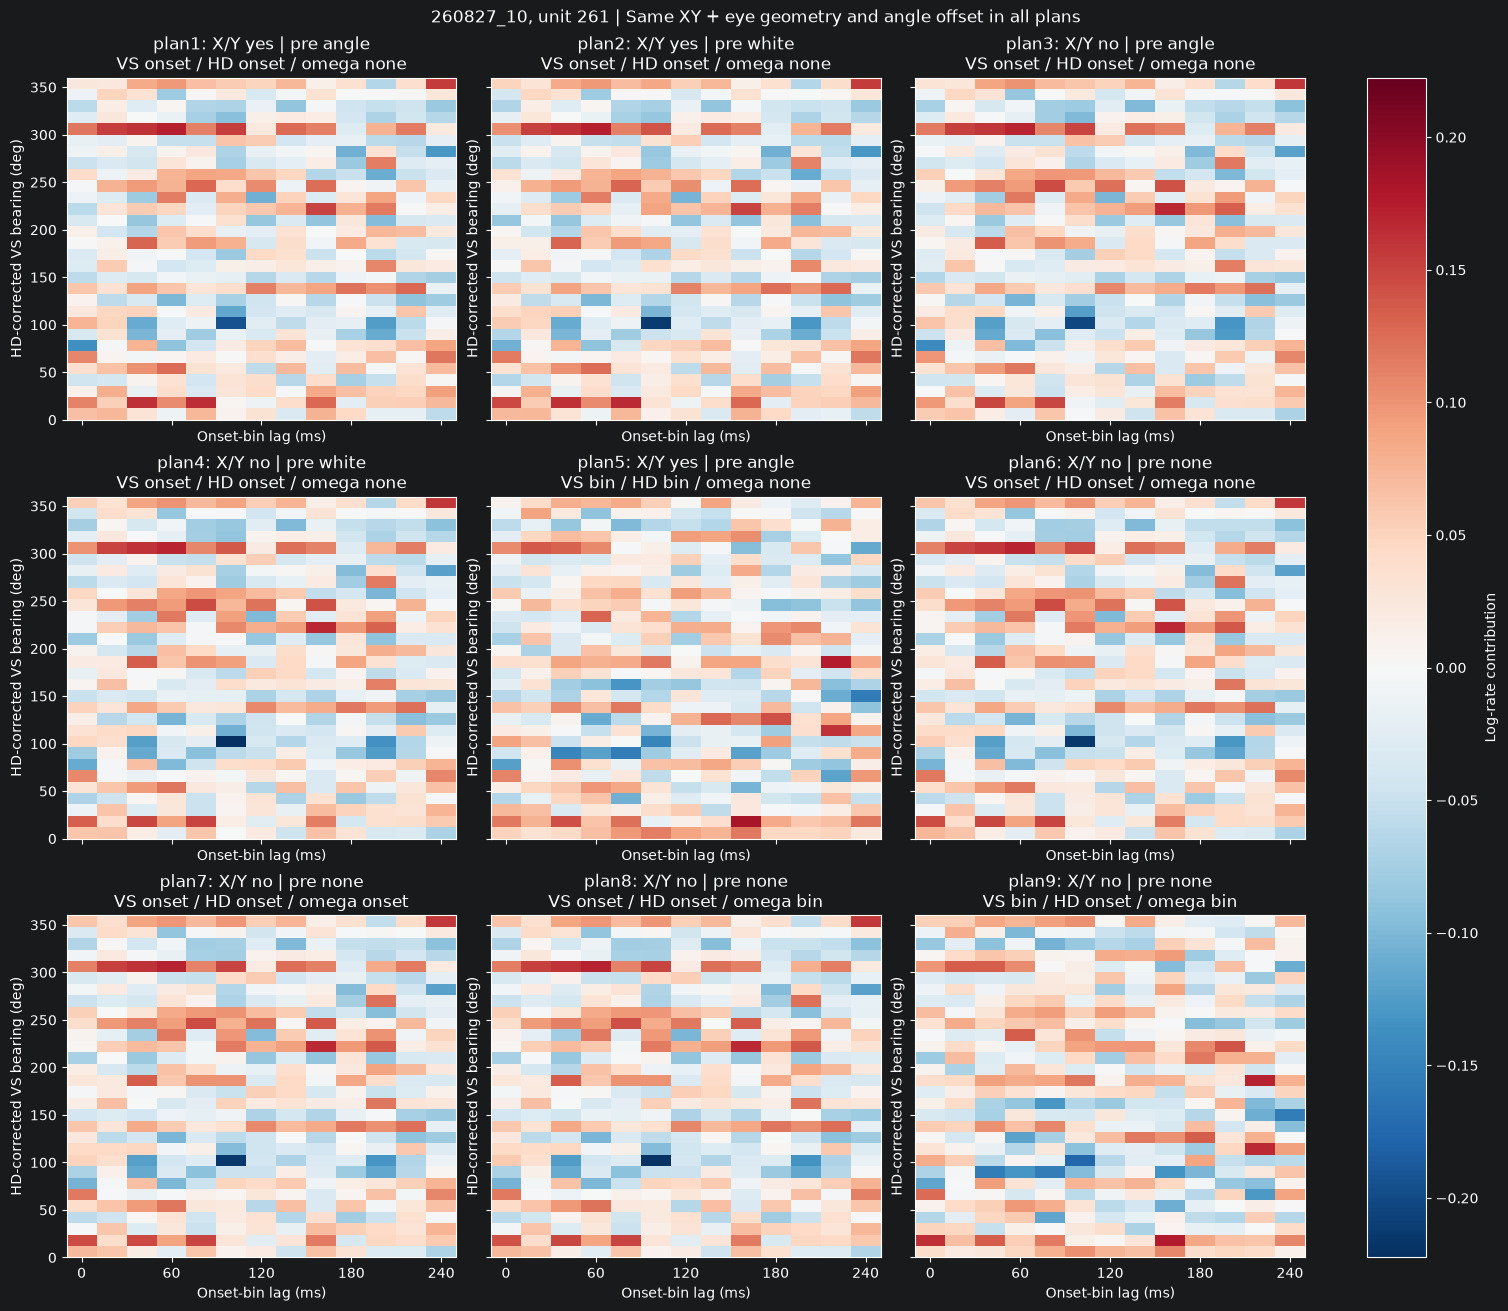

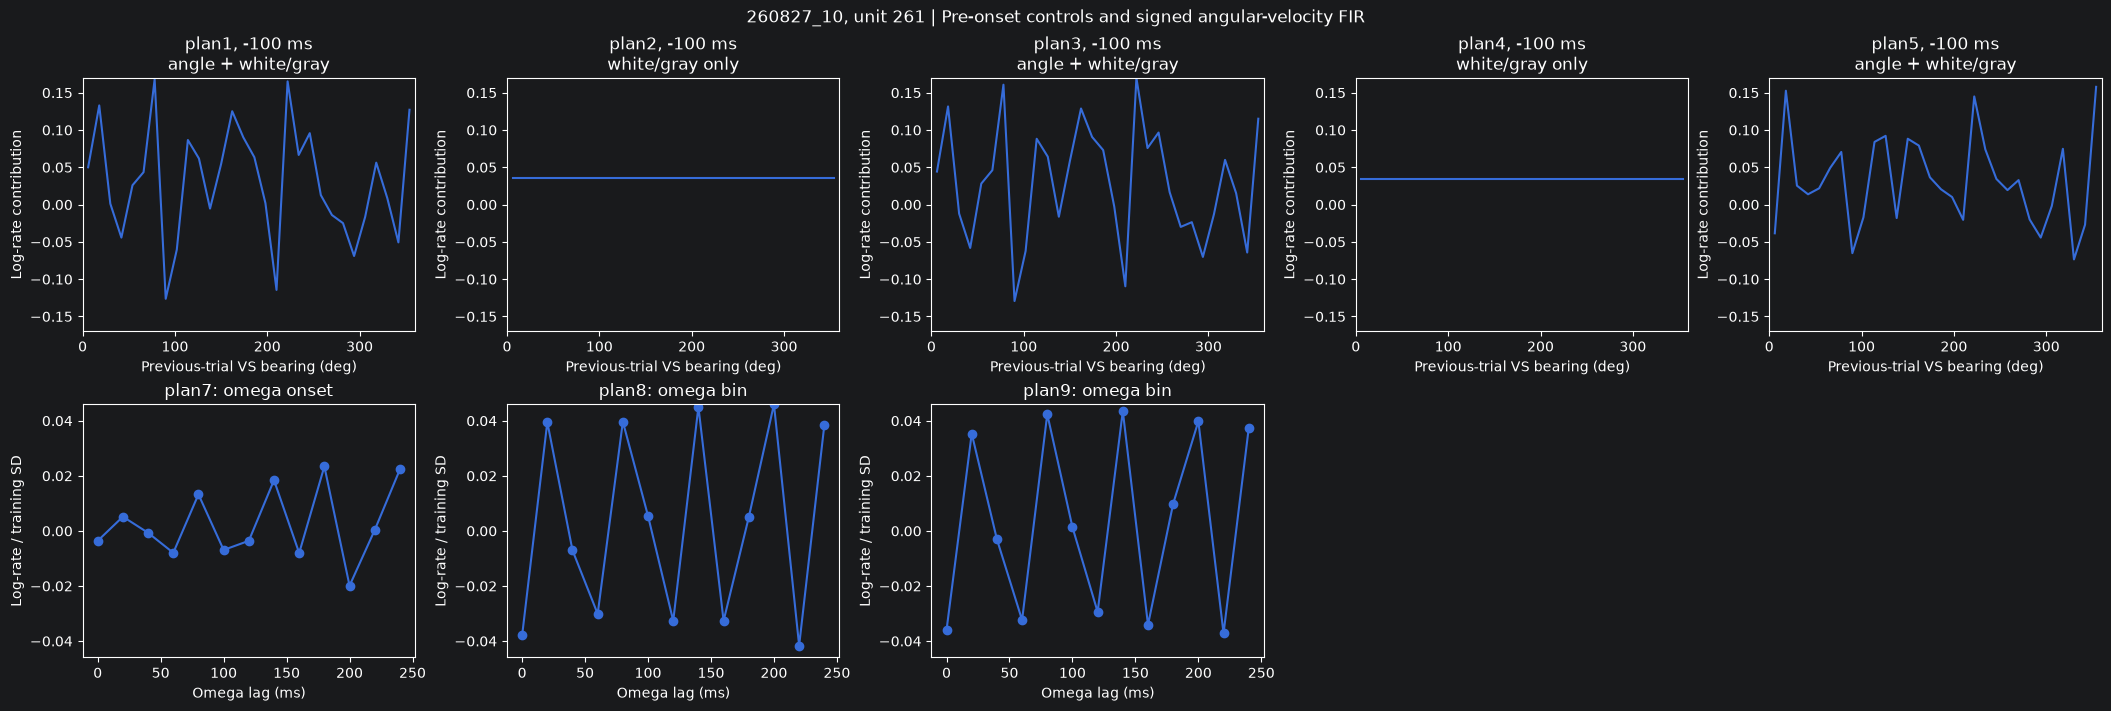

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(15, 13), sharex=True, sharey=True, layout="constrained")
limit = max(np.abs(panel).max() for panel in rf.values())
for axis, (name, spec) in zip(axes.flat, plan_specs.items()):
    plot = axis.pcolormesh(
        lags * 1000, angle_centers, rf[name], shading="nearest",
        cmap="RdBu_r", vmin=-limit, vmax=limit,
    )
    title = f"{name}: X/Y {'yes' if spec['xy'] else 'no'} | pre {spec['pre'] or 'none'}"
    title += f"\nVS {'bin' if spec['dynamic'] else 'onset'} / HD {'bin' if spec['hd_dynamic'] else 'onset'} / omega {spec['omega'] or 'none'}"
    axis.set(
        xlabel="Onset-bin lag (ms)", ylabel="HD-corrected VS bearing (deg)", ylim=(0, 360),
        xticks=lags[::3] * 1000, title=title,
    )
fig.colorbar(plot, ax=axes, label="Log-rate contribution")
fig.suptitle(f"{session_dir.name}, unit {unit_id} | Same XY + eye geometry and angle offset in all plans")
fig.savefig(output_dir / f"{unit_id}_plans.png", dpi=160)
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(21, 7), layout="constrained")
pre_limit = max(np.abs(panel).max() for panel in pre_rf.values())
for control_axis, (name, panel) in zip(axes[0], pre_rf.items()):
    spec = plan_specs[name]
    control_axis.plot(angle_centers, pre_rf[name])
    control_axis.set(
        xlabel="Previous-trial VS bearing (deg)", ylabel="Log-rate contribution",
        xlim=(0, 360), ylim=(-pre_limit, pre_limit),
        title=f"{name}, {pre_onset_lag * 1000:g} ms\n" + ("angle + white/gray" if spec["pre"] == "angle" else "white/gray only"),
    )
omega_limit = max(np.abs(panel).max() for panel in omega_kernels.values())
for axis, (name, kernel) in zip(axes[1], omega_kernels.items()):
    axis.plot(lags * 1000, kernel, "o-")
    axis.set(
        xlabel="Omega lag (ms)", ylabel="Log-rate / training SD", ylim=(-omega_limit, omega_limit),
        title=f"{name}: omega {plan_specs[name]['omega']}",
    )
for axis in axes[1, len(omega_kernels):]:
    axis.set_axis_off()
fig.suptitle(f"{session_dir.name}, unit {unit_id} | Pre-onset controls and signed angular-velocity FIR")
fig.savefig(output_dir / f"{unit_id}_plans_controls.png", dpi=160)
plt.show()


## 11. Compare the nine plans on identical held-out bins

1−3 and 2−4 measure additional X/Y; 1−2 and 3−4 measure −100 ms angle information;
5−1 measures updating both ego geometry and allocentric HD at each response-bin start.
6−3/4 removes the pre-onset control. 7−6 adds omega FIR; 8−7 updates omega sampling;
9−8 updates VS ego-pose sampling, retaining the same onset HD and bin-sampled omega.


In [12]:
test_log_likelihoods = {
    name: float(np.sum(spike_counts[test] * np.log(prediction[test]) - prediction[test]))
    for name, prediction in predicted_counts.items()
}
test_spike_count = int(spike_counts[test].sum())
bits_denominator = test_spike_count * np.log(2)
contrasts = {
    "xy_with_pre_angle_1_minus_3": ("plan1", "plan3"),
    "xy_with_pre_white_2_minus_4": ("plan2", "plan4"),
    "pre_angle_with_xy_1_minus_2": ("plan1", "plan2"),
    "pre_angle_without_xy_3_minus_4": ("plan3", "plan4"),
    "dynamic_pose_5_minus_1": ("plan5", "plan1"),
    "remove_pre_angle_6_minus_3": ("plan6", "plan3"),
    "remove_pre_white_6_minus_4": ("plan6", "plan4"),
    "add_onset_omega_7_minus_6": ("plan7", "plan6"),
    "bin_omega_8_minus_7": ("plan8", "plan7"),
    "bin_vs_pose_9_minus_8": ("plan9", "plan8"),
}
comparison = {
    "session": session_dir.name, "unit_id": unit_id,
    "bin_size_seconds": bin_size, "angle_bin_size_degrees": angle_bin_size,
    "lags_seconds": lags.tolist(), "pre_onset_lag_seconds": pre_onset_lag,
    "angle_convention": "existing (raw_position + 180 + HD + bearing_delta) % 360; offset unchanged",
    "pre_control": "trial at exact white onset -100 ms; gray is zero; shared white effect plus centered angle contrasts",
    "hd_sampling": "plan 5: response-bin start; all others: current trial onset",
    "dynamic_rf": "original onset bar position with response-bin-start XY, eye offset, and HD",
    "xy_sampling": "hp4 position at response-bin start; same covariates in plans 1, 2, 5",
    "hd_training_mean": hd_feature_mean.tolist(), "hd_training_scale": hd_feature_scale.tolist(),
    "xy_training_mean": xy_feature_mean.tolist(), "xy_training_scale": xy_feature_scale.tolist(),
    "omega_window_seconds": omega_window,
    "omega_definition": "(unwrapped HD(t) - unwrapped HD(t-0.05)) / 0.05, signed deg/s",
    "omega_sampling": "plan 7: trial onset held through trial; plans 8/9: bin start; FIR lags use past bins",
    "omega_training_mean": float(omega_feature_mean), "omega_training_scale": float(omega_feature_scale),
    "regularizer_strength": regularizer_strength,
    "train_bin_count": int(train.sum()), "test_bin_count": int(test.sum()),
    "test_spike_count": test_spike_count, "plans": plan_specs,
    "design_shapes": {name: list(design.shape) for name, design in designs.items()},
    "test_log_likelihoods": test_log_likelihoods,
    "gain_bits_per_spike": {
        label: (test_log_likelihoods[first] - test_log_likelihoods[second]) / bits_denominator
        for label, (first, second) in contrasts.items()
    },
}
(output_dir / f"{unit_id}_plans_comparison.json").write_text(json.dumps(comparison, indent=2) + "\n")
pd.DataFrame([
    {"plan": name, **plan_specs[name], "features": designs[name].shape[1], "test_log_likelihood": score}
    for name, score in test_log_likelihoods.items()
]), comparison["gain_bits_per_spike"]


(    plan     xy    pre  dynamic  hd_dynamic  omega  features  \
 0  plan1   True  angle    False       False    NaN       425   
 1  plan2   True  white    False       False    NaN       395   
 2  plan3  False  angle    False       False    NaN       423   
 3  plan4  False  white    False       False    NaN       393   
 4  plan5   True  angle     True        True    NaN       425   
 5  plan6  False    NaN    False       False    NaN       392   
 6  plan7  False    NaN    False       False  onset       405   
 7  plan8  False    NaN    False       False    bin       405   
 8  plan9  False    NaN     True       False    bin       405   
 
    test_log_likelihood  
 0         -7301.321121  
 1         -7297.688374  
 2         -7371.442953  
 3         -7367.813592  
 4         -7265.849437  
 5         -7368.551616  
 6         -7369.182281  
 7         -7370.035207  
 8         -7362.824194  ,
 {'xy_with_pre_angle_1_minus_3': np.float64(0.020971065335027704),
  'xy_with_pre_white